In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import adiabatic_approx_func as adprox
import kibble_zurek as kz

In [2]:
def defect_exact(n,state):
    return 1/2- Px(n,state)
def defect_approx(n,tau):
    return 1/2 - adprox.P_n(n,tau)



In [3]:
def omega(k):
    return np.sqrt((g - np.cos(k))**2 + np.sin(k)**2)

def uq(k):
    return np.sqrt((omega(k) + (g - np.cos(k))) / (2 * omega(k)))

def vq(k):
    return np.sin(k) / np.sqrt(2 * omega(k) * (omega(k) + (g -np.cos(k))))


In [12]:

L = 100
taus = np.logspace(0,3,200)

states = Parallel(n_jobs=-1)(
    delayed(state)(L, tau, tau) for tau in taus
)
T =1 
t = 1
g = 1 - t/T

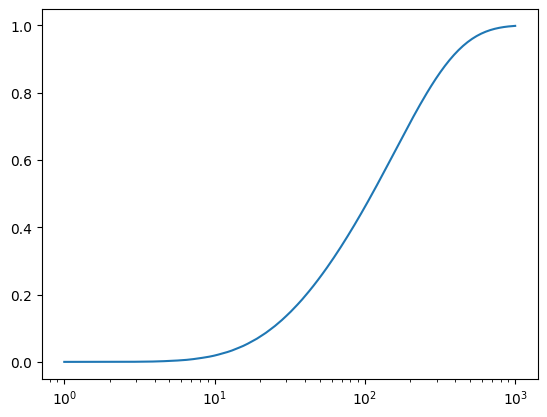

In [13]:
dat=[]
for s in states:
    u,v,k = s
    ug, vg = uq(k), vq(k)

    x = np.abs(ug*u+1j*vg*v)**2
    x = np.prod(x)
    dat.append(x)
dat = array(dat)
plot(taus,dat)
xscale("log")


In [14]:
ns = np.arange(1, 10 )
f_exact = np.zeros((len(ns), len(taus)))

def compute_col(j, st):
    return j, [
        defect_exact(n, st)
        for n in tqdm(ns, leave=False, desc=f"n (state {j})")
    ]

results = Parallel(n_jobs=-1)(
    delayed(compute_col)(j, st)
    for j, st in tqdm(list(enumerate(states)), desc="states")
)

for j, col in results:
    f_exact[:, j] = col

# append L to ns
ns = np.append(ns, L)

# append dat as a new row to f_exact
# dat must have length len(taus)
f_exact = np.vstack([f_exact, 1/2-np.asarray(dat)/2])


n (state 160):   0%|          | 0/9 [00:00<?, ?it/s]6it/s]  
/tmp/ipykernel_3059/826947654.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  f_exact[:, j] = col


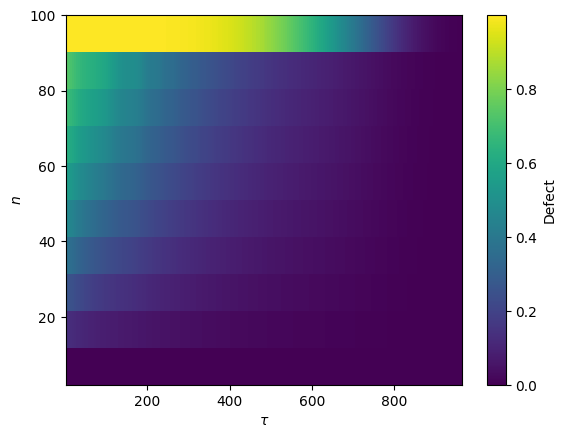

In [15]:
plt.figure()
#plt.xscale("log")
lim1=0
lim2=-1
img = plt.imshow(
    2 * f_exact[:, lim1:lim2],
    origin="lower",
    aspect="auto",
    interpolation="none",          # raw pixels
    extent=[taus[lim1], taus[lim2-1], ns[1], ns[-1]]
)

plt.colorbar(img, label="Defect")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$n$")
plt.show()


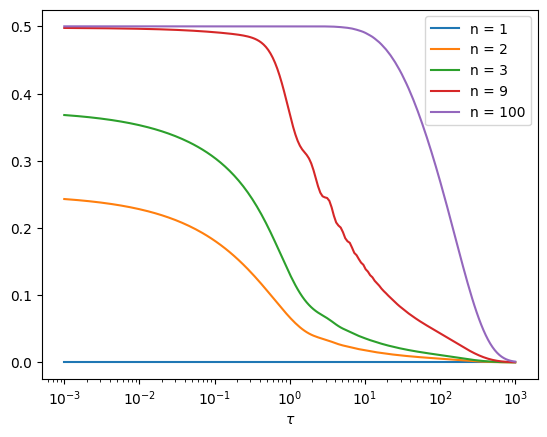

In [224]:

plt.figure()
coords = [0,1,2,-2,-1]
for coord in coords:
    plt.plot(taus, f_exact[coord, :], label=f"n = {ns[coord]}")
plt.xscale("log")
plt.xlabel(r"$\tau$")
plt.legend()
plt.show()

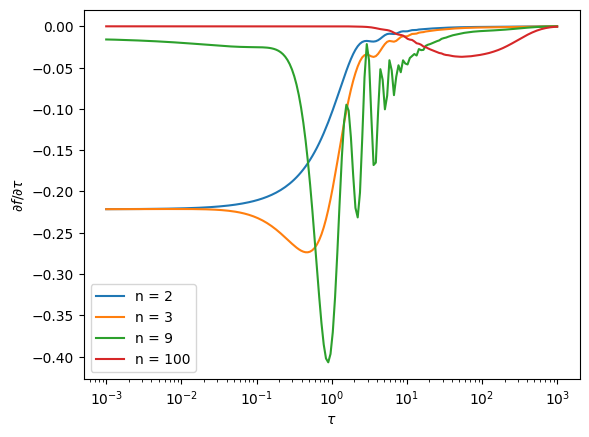

In [225]:

def d_dtau(y, tau):
    return np.gradient(y, tau**(1/2))

coords = [1,2,-2,-1]
for coord in coords:
    plt.plot(taus, d_dtau(f_exact[coord, :], taus), label=f"n = {ns[coord]}")

plt.xscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\partial f / \partial \tau$")
plt.legend()
plt.show()

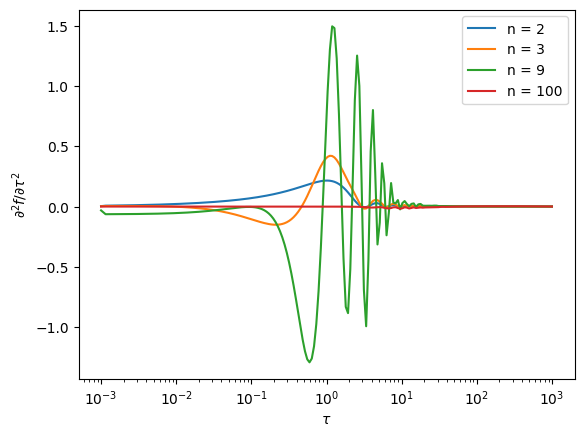

In [226]:
def d2_dtau2(y, tau):
    s = tau**0.5
    dy_ds = np.gradient(y, s)
    d2y_ds2 = np.gradient(dy_ds, s)
    return d2y_ds2

plt.figure()
for coord in coords:
    plt.plot(taus, d2_dtau2(f_exact[coord, :], taus),
             label=f"n = {ns[coord]}")

plt.xscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\partial^2 f / \partial \tau^2$")
plt.legend()
plt.show()


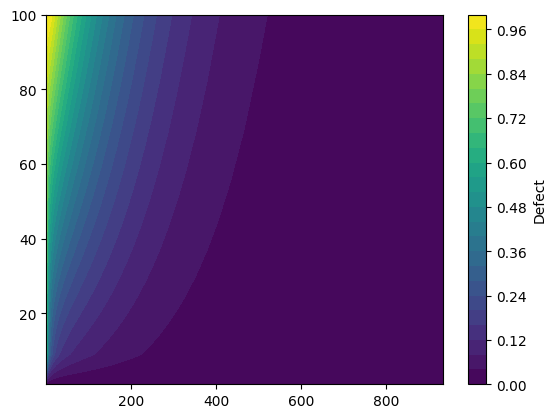

In [227]:
lim1=0
lim2=-1
cp = plt.contourf(taus[lim1:lim2], ns[:], 2*f_exact[:,lim1:lim2], levels=30)
plt.colorbar(cp, label='Defect')


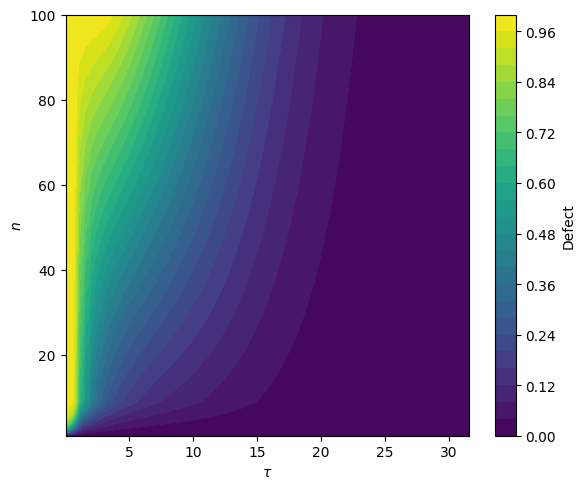

In [229]:
import matplotlib.pyplot as plt



N, T = f_exact.shape   # N = len(n_vals), T = len(tau_vals)

plt.figure(figsize=(6,5))
cp = plt.contourf(sqrt(taus), ns, f_exact*2, levels=30)

plt.xlabel(r'$\tau$')
plt.ylabel(r'$n$')
#plt.xscale('log')
plt.colorbar(cp, label='Defect')

plt.tight_layout()
plt.show()


In [18]:
# allocate grid
ns = [1,2,3,4,5,6,7,8,9,10,11,12]
f_approx = np.zeros((len(ns), len(taus)))   # shape (Nn , Nt)

# fill grid
for i, n in enumerate(ns):
    for j, tau in enumerate(taus):
        f_approx[i,j] = defect_approx(n, tau)


/tmp/ipykernel_3059/2143746078.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  f_approx[i,j] = defect_approx(n, tau)


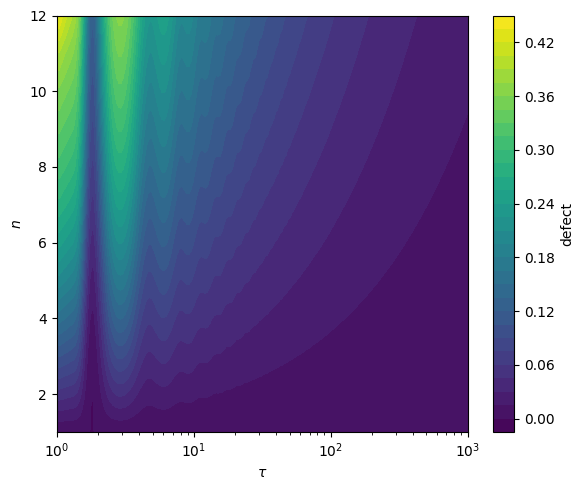

In [19]:
import matplotlib.pyplot as plt

N, T = f_approx.shape   # N = len(n_vals), T = len(tau_vals)

plt.figure(figsize=(6,5))
cp = plt.contourf(taus, ns, f_approx, levels=30)

plt.xlabel(r'$\tau$')
plt.ylabel(r'$n$')
plt.xscale('log')
plt.colorbar(cp, label='defect')

plt.tight_layout()
plt.show()


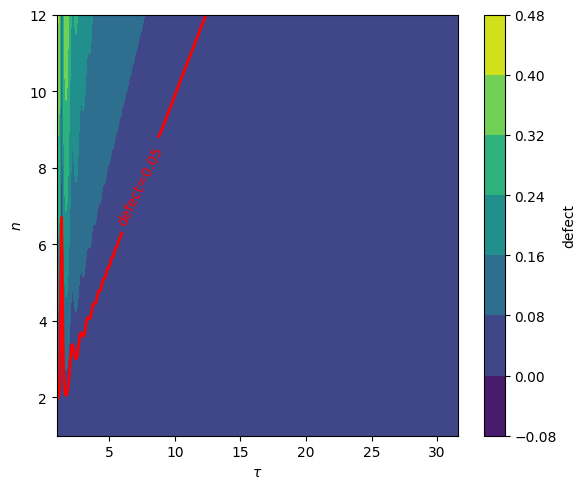

In [51]:
level = .05  # choose your constant value f(n,τ)=level

plt.figure(figsize=(6,5))
cp = plt.contourf(sqrt(taus), ns, f_approx, levels=5)
#plt.yscale("log")
#plt.xscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$n$")

# draw the constant-defect line
cs = plt.contour(sqrt(taus), ns, f_approx,levels=[level],colors="red", linewidths=2)

# optional label on the contour
plt.clabel(cs, fmt={level: f"defect={level}"})
plt.colorbar(cp, label='defect')
plt.tight_layout()

#xscale("log")

plt.show()


plot xlim = (np.float64(1.0), np.float64(31.622776601683793))


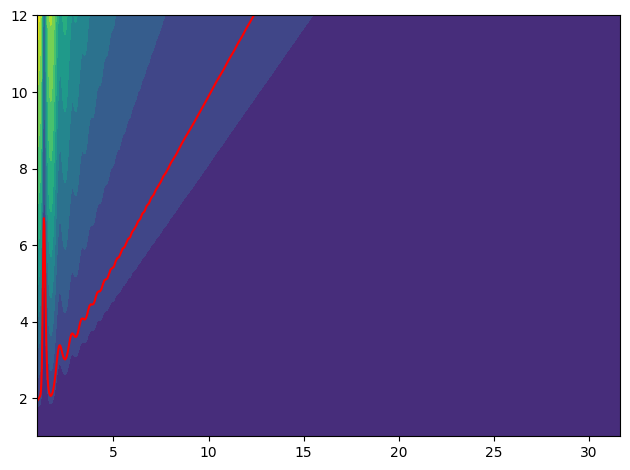

In [52]:
plt.figure()
plt.contourf(taus**(1/2), ns, f_approx, levels=10)
plt.contour(taus**(1/2), ns, f_approx, levels=[level], colors="red")
#plt.xscale("log")
plt.tight_layout()
print("plot xlim =", plt.xlim())
plt.show()


In [53]:
coords = []

# # horizontal crossings (fixed n)
# for i in range(len(ns)):
#     for j in range(len(taus)-1):
#         v1 = f_exact[i, j]
#         v2 = f_exact[i, j+1]
#         if (v1 - level) * (v2 - level) <= 0:
#             t1, t2 = taus[j], taus[j+1]
#             if v1 == v2:
#                 tau_cross = t1
#             else:
#                 tau_cross = t1 + (level - v1) * (t2 - t1) / (v2 - v1)
#             coords.append((tau_cross, ns[i]))

# vertical crossings (fixed τ)
for j in range(len(taus)):
    for i in range(len(ns)-1):
        v1 = f_approx[i, j]
        v2 = f_approx[i+1, j]
        if (v1 - level) * (v2 - level) <= 0:
            tau_cross = taus[j]
            if v1 == v2:
                n_cross = ns[i]
            else:
                n_cross = ns[i] + (level - v1) * (ns[i+1] - ns[i]) / (v2 - v1)
            coords.append((tau_cross, n_cross))


[]

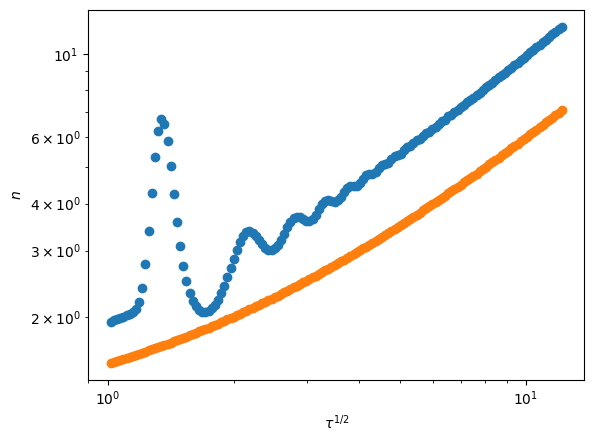

In [59]:
x = array([coord[1] for coord in coords])
y = array([coord[0] for coord in coords])

scatter(y**(1/2),x)

scatter(y**0.5,1/2*y**0.5+1)

xlabel(r"$\tau^{1/2}$")
ylabel(r"$n$")
#xlim(y[0]**(1/2),y[-1]**(1/2))
loglog()